In [41]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [42]:
BASE_DIR = Path("/home/nathan/Documents/Projects/IA/Projeto_IA_Tumor")

DATASET_DIR = BASE_DIR / "data/dataset"

OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
CONFUSION_DIR = OUTPUT_DIR / "confusion_matrix"

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.0001

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

RANDOM_SEED = 42

DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

In [43]:
class TumorDataset(Dataset):
    def __init__(self, samples, class_to_idx):
        self.samples = samples
        self.class_to_idx = class_to_idx

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        relative_path = str(image_path).split("dataset/")[-1]
        relative_path = relative_path.replace("/", "\\")

        image = Image.fromarray(image)
        image = self.transform(image)

        label = self.class_to_idx[class_name]

        return image, label

In [44]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [45]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)

print(f"Usando dispositivo: {DEVICE}")

all_samples = []
classes = []

for class_dir in sorted(DATASET_DIR.iterdir()):
    if class_dir.is_dir():
        class_name = class_dir.name
        classes.append(class_name)

        for image_path in class_dir.glob("*.jpg"):
            all_samples.append((image_path, class_name))

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

train_samples, temp_samples = train_test_split(
    all_samples,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=[x[1] for x in all_samples]
)

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=[x[1] for x in temp_samples]
)

train_dataset = TumorDataset(train_samples, class_to_idx)
val_dataset = TumorDataset(val_samples, class_to_idx)
test_dataset = TumorDataset(test_samples, class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Classes:", classes)
print("Total de imagens:", len(all_samples))
print("Imagens de treinamento:", len(all_samples))
print("Imagens de validacao:", len(val_samples))
print("Imagens de teste:", len(test_samples))

Usando dispositivo: cuda
Classes: ['Astrocytoma T2', 'Ependymoma T2', 'Glioma T2', 'Hemangiopericytoma T2', 'Meningioma T2', 'Neurocytoma T2', 'Normal T2', 'Oligodendroglioma T2', 'Other T2', 'Schwannoma T2']
Total de imagens: 2976
Imagens de treinamento: 2976
Imagens de validacao: 446
Imagens de teste: 447


In [46]:
model = BrainTumorCNN(num_classes=len(classes)).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []
val_accuracies = []

best_accuracy = 0

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_description(
            f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss.item():.4f}"
        )

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()

    val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    accuracy = accuracy_score(all_labels, all_preds)
    val_accuracies.append(accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Accuracy={accuracy:.4f}"
    )

    if accuracy > best_accuracy:
        best_accuracy = accuracy

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": class_to_idx,
            "accuracy": accuracy,
        }, MODEL_DIR / "best_model.pth")

print("Treinamento concluído")

Epoch 1/50 - Loss: 3.3422:  21%|██        | 27/131 [00:01<00:06, 15.35it/s]


KeyboardInterrupt: 

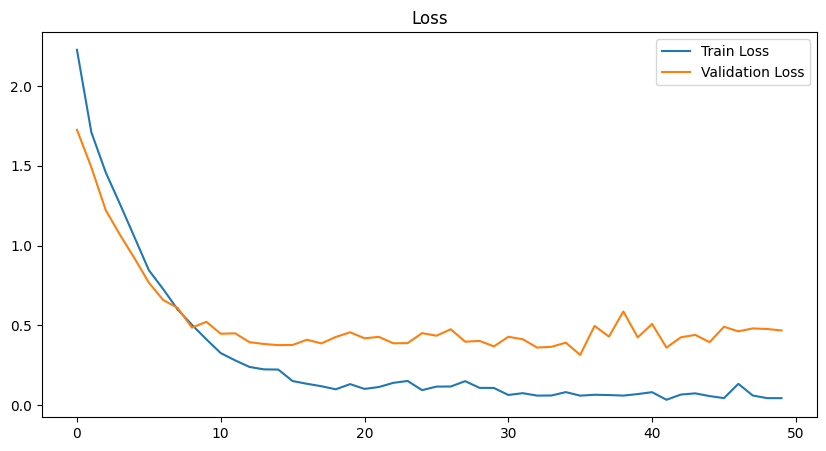

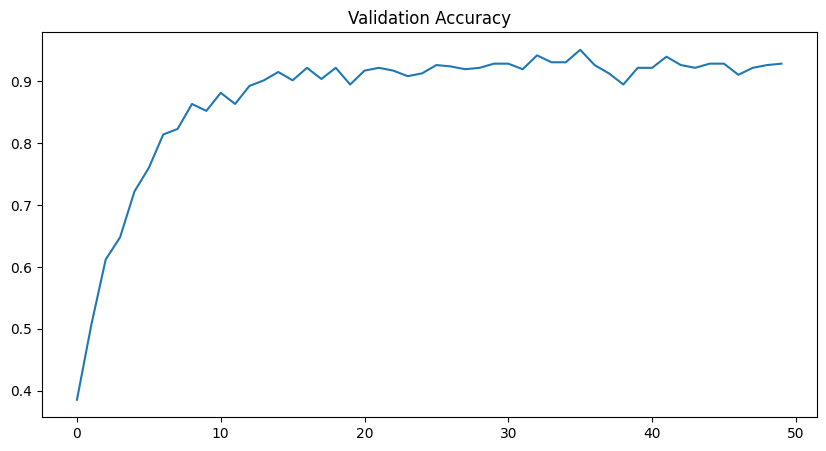

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.savefig(PLOT_DIR / "loss_curve.png")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.savefig(PLOT_DIR / "accuracy_curve.png")
plt.show()

In [ ]:
checkpoint = torch.load(MODEL_DIR / "best_model.pth")

model = BrainTumorCNN(num_classes=len(class_to_idx))
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)

model.eval()

test_dataset = TumorDataset(test_samples, class_to_idx)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)

print(f"Accuracy: {accuracy:.4f}")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_to_idx.keys()
))

Accuracy: 0.9575
                       precision    recall  f1-score   support

       Astrocytoma T2       0.97      0.88      0.93        42
        Ependymoma T2       1.00      1.00      1.00        53
            Glioma T2       0.97      0.98      0.98        61
Hemangiopericytoma T2       0.89      1.00      0.94        17
        Meningioma T2       0.96      0.96      0.96        69
       Neurocytoma T2       0.96      1.00      0.98        26
            Normal T2       0.89      0.98      0.93        57
 Oligodendroglioma T2       1.00      0.90      0.95        20
             Other T2       0.96      0.93      0.94        55
        Schwannoma T2       0.98      0.94      0.96        47

             accuracy                           0.96       447
            macro avg       0.96      0.96      0.96       447
         weighted avg       0.96      0.96      0.96       447



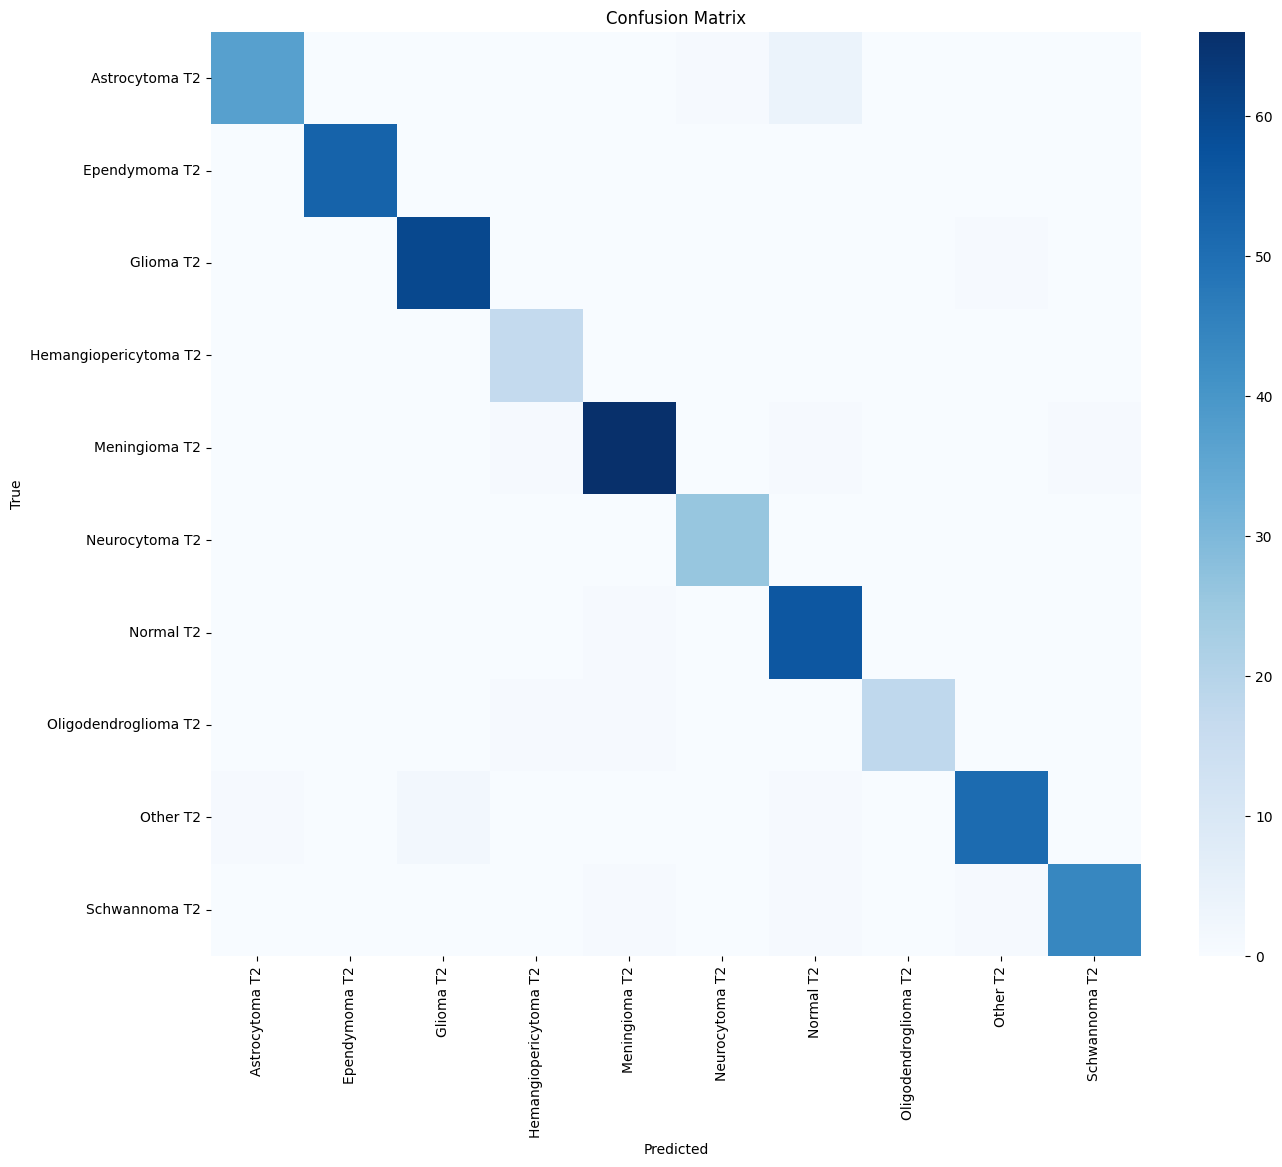

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_to_idx.keys(),
    yticklabels=class_to_idx.keys()
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(CONFUSION_DIR / "confusion_matrix.png")

plt.show()

Classe prevista: Astrocytoma T2
Confiança: 99.99%


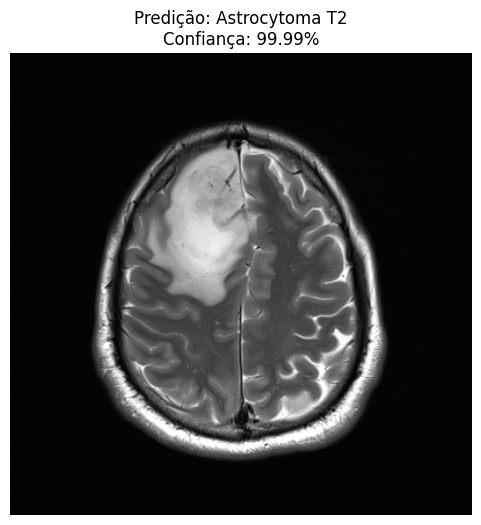

In [ ]:
image_path = "/home/nathan/Documents/Projects/IA/Projeto_IA_Tumor/data/dataset/Astrocytoma T2/T2 - Astrocytoma frontal , falx 009.jpg"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Imagem não encontrada: {image_path}")

# Transformações
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# Carrega imagem
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Erro ao carregar imagem")

# Mantém original para visualização
original_image = image.copy()

# PIL
image_pil = Image.fromarray(image)

# Tensor
image_tensor = transform(image_pil).unsqueeze(0).to(DEVICE)

# Inferência
model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = torch.softmax(output, dim=1)

    predicted_class = torch.argmax(probabilities, dim=1).item()

    confidence = probabilities[0][predicted_class].item()

predicted_label = idx_to_class[predicted_class]

print(f"Classe prevista: {predicted_label}")
print(f"Confiança: {confidence * 100:.2f}%")

# Exibe imagem
plt.figure(figsize=(6, 6))

plt.imshow(original_image, cmap="gray")

plt.title(
    f"Predição: {predicted_label}\n"
    f"Confiança: {confidence*100:.2f}%"
)

plt.axis("off")

plt.show()

In [ ]:
# Caminhos
final_model_path = MODEL_DIR / "final_model_weights.pth"

checkpoint_path = MODEL_DIR / "complete_checkpoint.pth"

# Salva pesos
torch.save(
    model.state_dict(),
    final_model_path
)

# Salva checkpoint completo
checkpoint = {

    "model_state_dict": model.state_dict(),

    "optimizer_state_dict": optimizer.state_dict(),

    "class_to_idx": class_to_idx,

    "idx_to_class": idx_to_class,

    "best_accuracy": best_accuracy,

    "epochs": EPOCHS,

    "learning_rate": LEARNING_RATE
}

torch.save(
    checkpoint,
    checkpoint_path
)

print("Modelo salvo com sucesso")

print(f"Pesos: {final_model_path}")

print(f"Checkpoint: {checkpoint_path}")

Modelo salvo com sucesso
Pesos: /home/nathan/Documents/Projects/IA/Projeto_IA_Tumor/outputs/models/final_model_weights.pth
Checkpoint: /home/nathan/Documents/Projects/IA/Projeto_IA_Tumor/outputs/models/complete_checkpoint.pth


In [ ]:
# Recria arquitetura
loaded_model = BrainTumorCNN(
    num_classes=len(class_to_idx)
)

# Carrega checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

# Carrega pesos
loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Move para dispositivo
loaded_model.to(DEVICE)

loaded_model.eval()

print("Modelo carregado com sucesso")

print(
    "Melhor accuracy:",
    checkpoint["best_accuracy"]
)

Modelo carregado com sucesso
Melhor accuracy: 0.9506726457399103


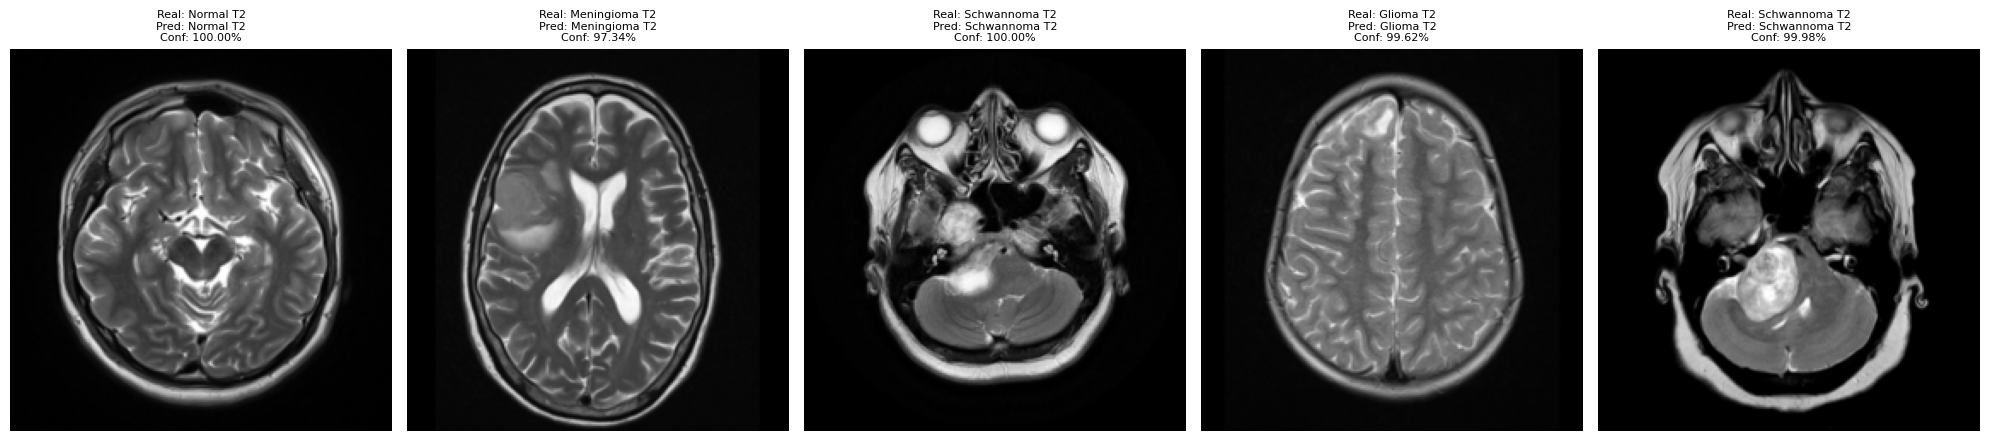

In [ ]:
num_images = 5

model.eval()

fig, axes = plt.subplots(
    1,
    num_images,
    figsize=(20, 5)
)

with torch.no_grad():

    for i in range(num_images):

        image, label = test_dataset[i]

        input_tensor = image.unsqueeze(0).to(DEVICE)

        # Forward
        output = model(input_tensor)

        # Probabilidades
        probabilities = torch.softmax(output, dim=1)

        # Classe prevista
        pred = torch.argmax(
            probabilities,
            dim=1
        ).item()

        # Confiança
        confidence = probabilities[0][pred].item()

        image_np = image.squeeze().cpu().numpy()

        axes[i].imshow(
            image_np,
            cmap="gray"
        )

        axes[i].set_title(
            f"Real: {idx_to_class[label]}\n"
            f"Pred: {idx_to_class[pred]}\n"
            f"Conf: {confidence*100:.2f}%",
            fontsize=8
        )

        axes[i].axis("off")

plt.tight_layout()

plt.show()

In [ ]:
print("=" * 50)
print("RESUMO FINAL DO TREINAMENTO")
print("=" * 50)

print(f"Número de classes: {len(classes)}")

print(f"Total de imagens: {len(all_samples)}")

print(f"Imagens treino: {len(train_samples)}")

print(f"Imagens validação: {len(val_samples)}")

print(f"Imagens teste: {len(test_samples)}")

print(
    f"\nMelhor accuracy: "
    f"{best_accuracy:.4f}"
)

print(
    f"Learning Rate: "
    f"{LEARNING_RATE}"
)

print(
    f"Batch Size: "
    f"{BATCH_SIZE}"
)

print(
    f"Épocas: "
    f"{EPOCHS}"
)

print(
    f"Dispositivo: "
    f"{DEVICE}"
)

print("=" * 50)

RESUMO FINAL DO TREINAMENTO
Número de classes: 10
Total de imagens: 2976
Imagens treino: 2083
Imagens validação: 446
Imagens teste: 447

Melhor accuracy: 0.9507
Learning Rate: 0.0001
Batch Size: 16
Épocas: 50
Dispositivo: cuda


In [ ]:
test_folder = DATASET_DIR / list(class_to_idx.keys())[0]

model.eval()

results = []

with torch.no_grad():

    for image_path in test_folder.glob("*.jpg"):

        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        image_pil = Image.fromarray(image)

        tensor = transform(image_pil)\
            .unsqueeze(0)\
            .to(DEVICE)

        output = model(tensor)

        probs = torch.softmax(output, dim=1)

        pred = torch.argmax(probs, dim=1).item()

        confidence = probs[0][pred].item()

        results.append({
            "image": image_path.name,
            "prediction": idx_to_class[pred],
            "confidence": confidence
        })

df_results = pd.DataFrame(results)

print(df_results.head())

                                               image      prediction  \
0  T2 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T2   
1  T2 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T2   
2  T2 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T2   
3  T2 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T2   
4            T2 - Anaplastic astrocytoma NOS 004.jpg  Astrocytoma T2   

   confidence  
0    0.989072  
1    0.972414  
2    0.997982  
3    0.988148  
4    0.999957  
